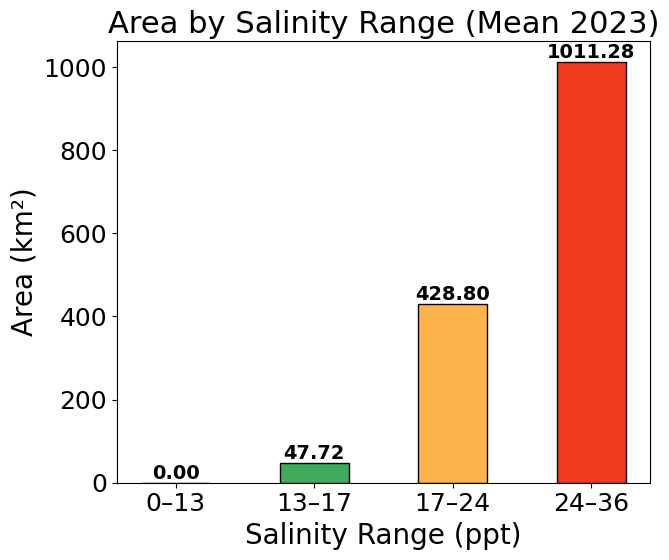

In [7]:
# --- Requirements ---
# pip install rasterio numpy matplotlib

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS

# ---------------- USER INPUT ----------------
raster_path = r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Mean_2023.tif"

# Salinity bins (ppt)
bins   = [0.0, 13.0, 17.0, 24.0, 36.0]
labels = ["0–13", "13–17", "17–24", "24–36"]
colors = ["#2c7fb8", "#41ab5d", "#feb24c", "#f03b20"]  # blue → green → orange → red
# ---------------------------------------------------

# ---- Load raster ----
with rasterio.open(raster_path) as src:
    arr = src.read(1).astype("float32")
    nodata = src.nodata
    src_crs = src.crs
    src_transform = src.transform
    src_bounds = src.bounds
    src_height, src_width = src.height, src.width

if nodata is not None:
    arr = np.where(arr == nodata, np.nan, arr)

# ---- Ensure projected CRS (meters) ----
target_crs = CRS.from_epsg(32614)
if (src_crs is None) or src_crs.is_geographic:
    transform_m, width_m, height_m = calculate_default_transform(
        src_crs, target_crs, src_width, src_height, *src_bounds
    )
    dst = np.full((height_m, width_m), np.nan, dtype="float32")
    reproject(
        source=arr,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=transform_m,
        dst_crs=target_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    work_arr = dst
    work_transform = transform_m
else:
    work_arr = arr
    work_transform = src_transform

# ---- Compute pixel area (m² → km²) ----
px_width = work_transform.a
px_height = work_transform.e
px_area_m2 = abs(px_width * px_height)
px_area_km2 = px_area_m2 / 1e6

# ---- Calculate area per salinity range ----
areas_km2 = []
for i in range(len(bins)-1):
    lo, hi = bins[i], bins[i+1]
    if i == len(bins)-2:
        mask = (work_arr >= lo) & (work_arr <= hi) & np.isfinite(work_arr)
    else:
        mask = (work_arr >= lo) & (work_arr < hi) & np.isfinite(work_arr)
    area = np.count_nonzero(mask) * px_area_km2
    areas_km2.append(area)

# ---- Plot colorful bar chart ----
plt.rcParams.update({
    "font.size": 20,        # base font size
    "axes.titlesize": 22,   # title font
    "axes.labelsize": 20,   # x/y label size
    "xtick.labelsize": 18,  # x tick labels
    "ytick.labelsize": 18,  # y tick labels
})

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(labels, areas_km2, color=colors, edgecolor="black", width=0.5)  # narrower bars

ax.set_xlabel("Salinity Range (ppt)")
ax.set_ylabel("Area (km²)")
ax.set_title("Area by Salinity Range (Mean 2023)")

# Add labels on top of bars
for i, v in enumerate(areas_km2):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=14, weight="bold")

# Clean layout
plt.tight_layout()
plt.show()
